In [1]:
%load_ext autoreload
%autoreload 2



# Basic libraries
import pandas as pd
import numpy as np
import sys



# Scipy
import scipy
from scipy import signal
from scipy.linalg import solve
from scipy import constants
from scipy.interpolate import interp1d
from scipy.fft import fft, fftfreq

# Locate files
import os
from pathlib import Path
from glob import glob

# Plots
from matplotlib import pyplot as plt

#Important!! Make sure your current directory is the MHDTurbPy folder!
import os
from pathlib import Path

root_dir  = r"C:\Users\nokni\work\MHDTurbPy_old"
os.chdir(root_dir)

spedas_dir = (Path(root_dir) / "data").resolve()
spedas_dir.mkdir(parents=True, exist_ok=True)
os.environ["SPEDAS_DATA_DIR"] = str(spedas_dir)

# Make sure to use the local spedas
sys.path.insert(0, os.path.join(os.getcwd(), 'pyspedas'))
import pyspedas
from pyspedas.utilities import time_string
from pytplot import get_data
from joblib import Parallel, delayed



""" Import manual functions """

sys.path.insert(1, os.path.join(os.getcwd(), 'functions'))
import calc_diagnostics as calc
import TurbPy as turb
import general_functions as func
import Figures as figs
import interactive_figs


from   SEA import SEA
import three_D_funcs as threeD
import download_data as download

sys.path.insert(1, os.path.join(os.getcwd(), 'functions/3d_anis_analysis_toolboox'))
import collect_wave_coeffs 
import data_analysis 



os.environ["CDF_LIB"] = "/Applications/cdf/cdf/lib"


In [6]:
settings['Data_path']

'C:\\Users\\nokni\\work\\MHDTurbPy_old'

In [14]:
func.delete_files_and_folders([str(Path(root_dir).joinpath('ace_data'))])

In [2]:
from pathlib import Path
from joblib import Parallel, delayed
import download_data as download

cdf_lib_path = "/Applications/cdf/cdf/lib"
credentials = None

settings = {
    "Data_path"         : Path(root_dir).joinpath('data'),
    "save_destination"  :  Path(root_dir).joinpath('examples').joinpath('downloaded_intervals'),
    "overwrite_files": 1,
    "save_all": True,
    "addit_time_around": 1,
    "gap_time_threshold": 5,
    "sc": "ACE",
    "in_rtn": False,
     "ace_frame" : "GSE",

    "start_date": "2025-10-01 00:00",
    "end_date": "2025-10-10 00:00",
    "multiple_intervals": False,
    "duration": "4H",
    "Step": "210min",

    "part_resol": 100,
    "MAG_resol": 100,
    "upsample_low_freq_ts": False,

    "must_have_qtn": False,
    "Max_par_missing": 30,

    "Big_Gaps": {
        "E_big_gaps": 10,
        "SC_pot_big_gaps": 10,
        "Mag_big_gaps": 10,
        "Par_big_gaps": 10,
        "QTN_big_gaps": 10,
    },
}

vars_2_downnload = {
    "mag": {"datatype": "h0"},   # MFI 16-sec L2
    "par": {"datatype": "h0"},   # SWEPAM 64-sec L2 (fallback to h2 inside ACE.py)
}
generated_interval_list = download.generate_intervals(
    settings["start_date"],
    settings["end_date"],
    settings["multiple_intervals"],
    data_path=settings["Data_path"],
    settings=settings,
)

save_path = Path(settings["save_destination"]).joinpath(settings["sc"])
save_path.mkdir(parents=True, exist_ok=True)

Parallel(n_jobs=1)(
    delayed(download.download_files)(
        jj,
        generated_interval_list,
        settings,
        vars_2_downnload,
        cdf_lib_path,
        credentials,
        save_path,
    )
    for jj in range(len(generated_interval_list))
)

12-Feb-26 08:37:48: Generating only one interval based on the provided start and end times.
12-Feb-26 08:37:48: Start Time: 2025-10-01 00:00:00
End Time: 2025-10-10 00:00:0000

12-Feb-26 08:37:48: Considering a single interval spanning: 2025-10-01 00:00:00 to 2025-10-10 00:00:00
Overwriting folder C:\Users\nokni\work\MHDTurbPy_old\examples\downloaded_intervals\ACE\2025-10-01_00-00-00_2025-10-10_00-00-00_sc_0
12-Feb-26 08:37:48: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/ace/mag/level_2_cdaweb/mfi_h0/2025/10-10_00-00-00_sc_0



=== ACE loader summary ===
Requested interval : 2025-10-01 00:00:00 -> 2025-10-10 00:00:00
Expanded interval  : 2025-10-01 00:00:00 -> 2025-10-10 00:00:00
Target cadences    : MAG=0.100s, PAR=0.100s
Velocity frame key : ace_frame=GSE (only used if we must manufacture V-components)


12-Feb-26 08:37:49: File is current: C:\Users\nokni\work\MHDTurbPy_old\data\ace\mag/level_2_cdaweb/mfi_h0/2025/ac_h0_mfi_20251001_v07.cdf
12-Feb-26 08:37:49: File is current: C:\Users\nokni\work\MHDTurbPy_old\data\ace\mag/level_2_cdaweb/mfi_h0/2025/ac_h0_mfi_20251002_v07.cdf
50: File is current: C:\Users\nokni\work\MHDTurbPy_old\data\ace\mag/level_2_cdaweb/mfi_h0/2025/ac_h0_mfi_20251003_v07.cdf

12-Feb-26 08:37:50: File is current: C:\Users\nokni\work\MHDTurbPy_old\data\ace\mag/level_2_cdaweb/mfi_h0/2025/ac_h0_mfi_20251004_v07.cdf
5_v07.cdf

12-Feb-26 08:37:51: File is current: C:\Users\nokni\work\MHDTurbPy_old\data\ace\mag/level_2_cdaweb/mfi_h0/2025/ac_h0_mfi_20251006_v07.cdf
7_v07.cdf

12-Feb-26 08:37:51: File is current: C:\Users\nokni\work\MHDTurbPy_old\data\ace\mag/level_2_cdaweb/mfi_h0/2025/ac_h0_mfi_20251008_v07.cdf
2: File is current: C:\Users\nokni\work\MHDTurbPy_old\data\ace\mag/level_2_cdaweb/mfi_h0/2025/ac_h0_mfi_20251009_v07.cdf

12-Feb-26 08:37:56: Downloading remote inde

0 : Magnitude
1 : BGSEc
2 : BGSM
3 : dBrms
4 : SC_pos_GSE
5 : SC_pos_GSM
--- MAG ---
Source            : pyspedas:ace.mfi:h0
Returned coverage : 2025-10-01 00:00:07 -> 2025-10-09 23:59:49
Columns           : ['Bx', 'By', 'Bz']
--- PAR ---
CDAWeb skipped     : requested start 2025-10-01 00:00:00 is after 2024-07-09 23:59:59


12-Feb-26 08:37:57: Remote index not found: https://spdf.gsfc.nasa.gov/pub/data/ace/swepam/level_2_cdaweb/swe_h0/2025/
12-Feb-26 08:37:59: Skipping remote index: https://spdf.gsfc.nasa.gov/pub/data/ace/swepam/level_2_cdaweb/swe_h0/2025/ (previous attempt failed)

12-Feb-26 08:37:59: Skipping remote index: https://spdf.gsfc.nasa.gov/pub/data/ace/swepam/level_2_cdaweb/swe_h0/2025/ (previous attempt failed)

12-Feb-26 08:37:59: Skipping remote index: https://spdf.gsfc.nasa.gov/pub/data/ace/swepam/level_2_cdaweb/swe_h0/2025/ (previous attempt failed)

12-Feb-26 08:37:59: Skipping remote index: https://spdf.gsfc.nasa.gov/pub/data/ace/swepam/level_2_cdaweb/swe_h0/2025/ (previous attempt failed)

12-Feb-26 08:37:59: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/ace/swepam/level_2_cdaweb/swe_k0/2025/
File is current: C:\Users\nokni\work\MHDTurbPy_old\data\ace\swepam/level_2_cdaweb/swe_k0/2025/ac_k0_swe_20251001_v01.cdf
12-Feb-26 08:37:59: File is current: C:\Users\nokni\work\MH

0 : Np
1 : Vp
2 : He_ratio
3 : Tpr
--- PAR ---
Source            : pyspedas:ace.swe:k0
Returned coverage : 2025-10-01 00:00:00 -> 2025-10-09 23:55:00
Vector columns    : ['Vx', 'Vy', 'Vz']
Vector note       : manufactured only because fallback had only Vp; used V*=Vp/sqrt(3)
Thermals          : Tp[eV], Tp_K[K], Vth[km/s] computed (WIND-consistent)
Key columns       : ['Tp', 'Tp_K', 'Vp', 'Vth', 'Vx', 'Vy', 'Vz', 'np']
--- Cadence check (selected interval) ---
MAG native cadence : ~16.000s (median Δt over selected interval)
MAG note           : requested cadence 0.100s is HIGHER than native
PAR native cadence : ~300.000s (median Δt over selected interval)
PAR note           : requested cadence 0.100s is HIGHER than native
--- Diagnostics ---
Mag fraction missing: 0.0
Par fraction missing: 3.5108024691358026
=== ACE loader done ===
Index(['Bx', 'By', 'Bz', 'Vp', 'np', 'Tp', 'Vx', 'Vy', 'Vz', 'Tp_K', 'Vth',
       'TEMP', 'Bx_mean', 'By_mean', 'Bz_mean', 'Vx_mean', 'Vy_mean',
       'Vz_m

[None]

In [3]:
%matplotlib tk

from pathlib import Path
import matplotlib.pyplot as plt
import interactive_figs
import general_functions as func

plt.close("all")

sc = "ACE"
which_int = 0
load_path = Path(root_dir).joinpath('examples').joinpath('downloaded_intervals').joinpath(sc)
save_path = Path(root_dir).joinpath("selected_intervals")

# ============================================================
# ONE run that does BOTH:
# (A) add one extra curve to an existing panel (panel 0)
# (B) append a brand-new extra panel (8th subplot)
# ============================================================
panel_edits = {
    # (A) add one extra curve to an existing panel
    "add_series": {
        "panel_idx": 0,   # top panel
        "axis_idx": 0,    # first axis-spec in that panel (left axis)
        "series": {
            "kind": "col",
            "col": "B_RTN",
            "label": r"$|B|$ (extra dashed)",
            "style": {"lw": 1.0, "ls": "--", "ms": 0, "color": "0.35"},
        },
    },

    # (B) append a new panel at the bottom
    "add_panels": {
        "where": "append",
        "panel": {
            "axes": [
                {
                    "axis_id": "left",
                    "source": "Par",
                    "scale": "linear",
                    "series": [
                        {
                            "kind": "col",
                            "col": "Vth",
                            "label": r"$T_p~[eV]$ (extra panel)",
                            "style": {"lw": 0.8, "ls": "-", "ms": 0, "color": "k"},
                        }
                    ],
                    "legend": {"fontsize": "small", "frameon": False, "bbox_to_anchor": (1.01, 1), "loc": 2},
                    "hline": [{"y": 100.0, "ls": ":", "c": "0.3", "lw": 1.2}],
                }
            ]
        },
    },

    # (c) More

    
}

fig, events = interactive_figs.interactive_mhdturbpy_interval(
    sc=sc,
    which_int=which_int,
    load_path=load_path,
    my_dir=root_dir,
    save_path=save_path,
    rolling=None,
    resample_rule=None,
    fill_method=None,
    gap_thresholds={"mag": "30s", "par": "30s", "qtn": "30s", "sc_pot": "30s"},
    load_files_func=func.load_files,
    autosave=True,
    resume=True,
    export_csv=True,
    snap_to_data=False,
    enable_comments=True,
    debug_interaction=True,
    panel_config=None,          # use defaults
    panel_edits=panel_edits,    # add curve + append panel
    auto_ylims=True,
    debug_plot_config=True,     # should print n_panels=8
)

plt.show()


[plot] n_panels=8
[plot:missing] panel=6 sc=ACE axis=left source=Par func=Rsun_from_au failed (KeyError: 'Rsun_from_au(): missing Dist_au') -> omitted
icker] installed mpl(cids=17,None,18,19) + tkbinds=3c=Rsun_from_au failed (KeyError: 'Rsun_from_au(): missing Dist_au') -> omitted

[picker] left_select_fallback(default)=True  (toggle with 'l')m_au failed (KeyError: 'Rsun_from_au(): missing Dist_au') -> omitted


dedupe_ms=250  dedupe_tol_ns=5000000  span_axes=8 marker_axes=10  move_throttle_ms=33  use_release_event=False -> omitted



[picker:mpl:recv] name=button_press_event button=1 key=None inaxes=True xdata=20365.399694561704 toolbar_mode='zoom rect'




ignored] reason=toolbar_modet button=1 key=None inaxes=True xdata=20365.399694561704 toolbar_mode='zoom rect'





[picker:mpl:recv] name=button_press_event button=1 key=None inaxes=True xdata=20365.706215410093 toolbar_mode='zoom rect'
ignored] reason=toolbar_modet button=1 key=None inaxes=True xdata=20365.706215410093 toolbar_mod

In [137]:
%matplotlib tk

from pathlib import Path
import matplotlib.pyplot as plt
import interactive_figs
import general_functions as func

plt.close("all")

sc = [ 'WIND']#', "ACE"]

which_int                   = 3 # only needs to exist for first spacecraft when align_intervals_to_first_sc=True
align_intervals_to_first_sc = True
rolling_mean                = '1min'


load_path = {
    #"ACE":  r"C:\Users\nokni\work\MHDTurbPy_old\examples\ACE",
    "WIND": r"C:\Users\nokni\work\MHDTurbPy_old\examples\WIND",
}

my_dir = r"C:\Users\nokni\work\MHDTurbPy_old\examples"
save_path = Path(my_dir) / "selected_intervals"
panel_edits =None
# panel_edits = {
#     "add_series": {
#         "panel_idx": 0,
#         "axis_idx": 0,
#         "series": {
#             "kind": "col",
#             "col": "B_RTN",
#             "label": r"$|B|~[nT]$ (extra)",   # include units if you want this series eligible for normalization
#             "style": {"lw": 1.0, "ls": "--", "ms": 0, "color": "0.35"},
#         },
#     },
#     "add_panels": {
#         "where": "append",
#         "panel": {
#             "axes": [
#                 {
#                     "axis_id": "left",
#                     "source": "Par",
#                     "scale": "linear",
#                     "series": [
#                         {
#                             "kind": "col",
#                             "col": "Vth",
#                             "label": r"$T_p~[eV]$ (extra panel)",
#                             "style": {"lw": 0.8, "ls": "-", "ms": 0, "color": "k"},
#                         }
#                     ],
#                     "legend": {"fontsize": "small", "frameon": False, "bbox_to_anchor": (1.01, 1), "loc": 2},
#                     "hline": [{"y": 100.0, "ls": ":", "c": "0.3", "lw": 1.2}],
#                 }
#             ]
#         },
#     },
# }

fig, events = interactive_figs.interactive_mhdturbpy_interval(
    sc=sc,
    which_int=which_int,
    load_path=load_path,
    my_dir=my_dir,
    save_path=save_path,
    rolling= rolling_mean,
    resample_rule=None,
    fill_method=None,
    gap_thresholds={"mag": "30s", "par": "30s", "qtn": "30s", "sc_pot": "30s"},
    load_files_func=func.load_files,
    autosave=True,
    resume=True,
    export_csv=True,
    snap_to_data=False,
    enable_comments=True,
    debug_interaction=True,

    # helpful to verify selected idx per spacecraft:
    debug_plot_config=True,

    panel_config=None,
    panel_edits=panel_edits,
    auto_ylims=True,

    # New/important knobs:
    enforce_sc_linestyle=True,            # same linestyle per spacecraft across all panels
    normalize_timeseries="None",        # choose: None/"none","zscore","minmax","median","first"
    align_intervals_to_first_sc=align_intervals_to_first_sc,     # auto-pick closest interval for non-first spacecraft
    snap_index_mode="union",              # "first_sc" or "union"
)

plt.show()


[plot] n_panels=7
[plot:missing] panel=6 sc=WIND axis=left source=Par func=Rsun_from_au failed (KeyError: 'Rsun_from_au(): missing Dist_au') -> omitted
[picker] resumed 0 intervals from C:\Users\nokni\work\MHDTurbPy_old\examples\selected_intervals\selected_intervals_2025_11_20_2025_11_29_WIND.pkl
[picker] installed mpl(cids=16,None,17,18) + tkbinds=3
[picker] left_select_fallback(default)=True  (toggle with 'l')
[picker] dedupe_ms=250  dedupe_tol_ns=5000000  span_axes=7 marker_axes=9  move_throttle_ms=33  use_release_event=False


In [10]:
from __future__ import annotations

import math
from dataclasses import dataclass
from typing import Iterable, Optional

import numpy as np
import pandas as pd
import requests
from astroquery.jplhorizons import Horizons


HORIZONS_LOOKUP_URL = "https://ssd.jpl.nasa.gov/api/horizons_lookup.api"


@dataclass(frozen=True)
class LonLatSeries:
    df: pd.DataFrame
    lon_deg_col: str = "lon_deg"
    lat_deg_col: str = "lat_deg"


def lookup_spkid_spacecraft(s: str) -> str:
    """
    Resolve a user string to a Horizons SPK ID, restricting matches to spacecraft.
    Uses the JPL Horizons Lookup API (group=sct).
    """
    r = requests.get(HORIZONS_LOOKUP_URL, params={"sstr": s, "group": "sct", "format": "json"}, timeout=30)
    r.raise_for_status()
    payload = r.json()

    count = int(payload.get("count", 0))
    if count == 0:
        raise ValueError(f"No spacecraft match found for: {s!r}")

    results = payload["result"]
    if len(results) == 1:
        return results[0]["spkid"]

    # If multiple spacecraft match, pick the exact-name match if possible; else first.
    s_lower = s.strip().lower()
    for item in results:
        name = str(item.get("name", "")).strip().lower()
        if name == s_lower or name.startswith(s_lower + " "):
            return item["spkid"]
    return results[0]["spkid"]


def horizons_vectors(
    spkid_or_name: str,
    start_utc: str,
    stop_utc: str,
    step: str,
    center: str = "@sun",
    refplane: str = "ecliptic",
) -> pd.DataFrame:
    """
    Fetch vectors from JPL Horizons using astroquery.

    Returns a DataFrame indexed by UTC datetime, with columns:
      x_au, y_au, z_au, vx_au_d, vy_au_d, vz_au_d
    """
    epochs = {"start": start_utc, "stop": stop_utc, "step": step}
    obj = Horizons(id=spkid_or_name, location=center, epochs=epochs)
    tab = obj.vectors(refplane=refplane)

    t = pd.to_datetime(np.array(tab["datetime_str"]), utc=True)
    df = pd.DataFrame(
        {
            "x_au": np.array(tab["x"], dtype=float),
            "y_au": np.array(tab["y"], dtype=float),
            "z_au": np.array(tab["z"], dtype=float),
            "vx_au_d": np.array(tab["vx"], dtype=float),
            "vy_au_d": np.array(tab["vy"], dtype=float),
            "vz_au_d": np.array(tab["vz"], dtype=float),
        },
        index=t,
    )
    df.index.name = "utc"
    return df


def xyz_to_lonlat_deg(x: np.ndarray, y: np.ndarray, z: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Convert Sun-centered Cartesian coordinates (same units) to spherical lon/lat in degrees:
      lon = atan2(y, x) in [-180, 180)
      lat = atan2(z, sqrt(x^2+y^2)) in [-90, 90]
    """
    lon = np.degrees(np.arctan2(y, x))
    r_xy = np.sqrt(x * x + y * y)
    lat = np.degrees(np.arctan2(z, r_xy))
    # Normalize lon to [-180, 180)
    lon = (lon + 180.0) % 360.0 - 180.0
    return lon, lat


def get_lonlat_timeseries(
    target: str,
    start_utc: str,
    stop_utc: str,
    step: str,
    try_aliases: Optional[Iterable[str]] = None,
    center: str = "@sun",
    refplane: str = "ecliptic",
) -> LonLatSeries:
    """
    Resolve spacecraft target -> SPK ID -> vectors -> lon/lat.
    `try_aliases` lets you provide fallback query strings (useful for SOLAR-1 vs SWFO-L1).
    """
    candidates = [target] + list(try_aliases or [])
    last_err: Optional[Exception] = None

    spkid = None
    for c in candidates:
        try:
            spkid = lookup_spkid_spacecraft(c)
            break
        except Exception as e:
            last_err = e

    if spkid is None:
        raise ValueError(f"Could not resolve spacecraft {target!r}. Last error: {last_err}")

    df = horizons_vectors(spkid, start_utc, stop_utc, step, center=center, refplane=refplane)
    lon, lat = xyz_to_lonlat_deg(df["x_au"].to_numpy(), df["y_au"].to_numpy(), df["z_au"].to_numpy())
    df["lon_deg"] = lon
    df["lat_deg"] = lat
    df["spkid"] = spkid
    df["target_query"] = target
    return LonLatSeries(df=df)


In [21]:
from __future__ import annotations

import argparse
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import plotly.graph_objects as go

#from horizons_lonlat import get_lonlat_timeseries


DEFAULT_ALIASES = {
    "SOLAR-1": ["SWFO-L1", "Space weather Observations at L1 to Advance Readiness - 1"],
    "SWFO-L1": ["SOLAR-1", "Space weather Observations at L1 to Advance Readiness - 1"],
    "IMAP": ["Interstellar Mapping and Acceleration Probe"],
    "ACE": ["Advanced Composition Explorer"],
    "WIND": ["Wind"],
}


def _au_to_r(x_au: np.ndarray, y_au: np.ndarray, z_au: np.ndarray) -> np.ndarray:
    return np.sqrt(x_au * x_au + y_au * y_au + z_au * z_au)


def build_figure(series: Dict[str, pd.DataFrame], title: str) -> go.Figure:
    names = list(series.keys())
    t = series[names[0]].index
    nT = len(t)

    fig = go.Figure()

    for name in names:
        df = series[name]
        fig.add_trace(
            go.Scatter3d(
                x=df["x_au"],
                y=df["y_au"],
                z=df["z_au"],
                mode="lines",
                name=f"{name} (traj)",
            )
        )
        fig.add_trace(
            go.Scatter3d(
                x=[df["x_au"].iloc[0]],
                y=[df["y_au"].iloc[0]],
                z=[df["z_au"].iloc[0]],
                mode="markers",
                name=f"{name} (t)",
            )
        )

    # Sun marker
    fig.add_trace(go.Scatter3d(x=[0.0], y=[0.0], z=[0.0], mode="markers", name="Sun"))

    # Frames update only the marker traces (2 per target), plus an annotation panel.
    frames = []
    marker_trace_indices = []
    for i, name in enumerate(names):
        marker_trace_indices.append(2 * i + 1)  # (traj=2*i, marker=2*i+1)

    for k in range(nT):
        data_updates = []
        for i, name in enumerate(names):
            df = series[name]
            data_updates.append(
                go.Scatter3d(
                    x=[df["x_au"].iloc[k]],
                    y=[df["y_au"].iloc[k]],
                    z=[df["z_au"].iloc[k]],
                    mode="markers",
                )
            )

        lines = [f"<b>{t[k].strftime('%Y-%m-%d %H:%M UTC')}</b>"]
        for name in names:
            df = series[name]
            lines.append(
                f"{name}: lon={df['lon_deg'].iloc[k]:8.3f} deg, lat={df['lat_deg'].iloc[k]:8.3f} deg, r={_au_to_r(df['x_au'].iloc[k], df['y_au'].iloc[k], df['z_au'].iloc[k]):.6f} AU"
            )

        frames.append(
            go.Frame(
                name=str(k),
                data=data_updates,
                traces=marker_trace_indices,
                layout=go.Layout(
                    annotations=[
                        go.layout.Annotation(
                            x=0.02,
                            y=0.98,
                            xref="paper",
                            yref="paper",
                            showarrow=False,
                            align="left",
                            text="<br>".join(lines),
                            bordercolor="black",
                            borderwidth=1,
                            bgcolor="white",
                            opacity=0.9,
                        )
                    ]
                ),
            )
        )

    fig.frames = frames

    steps = []
    for k in range(nT):
        steps.append(
            dict(
                method="animate",
                args=[
                    [str(k)],
                    dict(frame=dict(duration=0, redraw=True), mode="immediate", transition=dict(duration=0)),
                ],
                label=str(k),
            )
        )

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="x [AU]",
            yaxis_title="y [AU]",
            zaxis_title="z [AU]",
            aspectmode="data",
        ),
        updatemenus=[
            dict(
                type="buttons",
                showactive=False,
                x=0.02,
                y=0.02,
                xanchor="left",
                yanchor="bottom",
                buttons=[
                    dict(
                        label="Play",
                        method="animate",
                        args=[None, dict(frame=dict(duration=60, redraw=True), fromcurrent=True)],
                    ),
                    dict(
                        label="Pause",
                        method="animate",
                        args=[[None], dict(frame=dict(duration=0, redraw=False), mode="immediate")],
                    ),
                ],
            )
        ],
        sliders=[
            dict(
                x=0.15,
                y=0.02,
                len=0.8,
                currentvalue=dict(prefix="t index = "),
                steps=steps,
            )
        ],
    )
    return fig


def main() -> None:
    p = argparse.ArgumentParser()
    p.add_argument("--start", required=True, help="UTC start, e.g. 2026-01-20T00:00")
    p.add_argument("--stop", required=True, help="UTC stop, e.g. 2026-01-27T00:00")
    p.add_argument("--step", default="1h", help="Horizons step, e.g. 5m, 1h, 6h, 1d")
    p.add_argument("--targets", nargs="+", default=["IMAP", "SOLAR-1", "ACE", "WIND"])
    p.add_argument("--outdir", default="out_orbits_lonlat")
    p.add_argument("--html", default="orbits_lonlat.html")
    args = p.parse_args()

    outdir = Path(args.outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    series: Dict[str, pd.DataFrame] = {}
    for tgt in args.targets:
        aliases = DEFAULT_ALIASES.get(tgt, [])
        ts = get_lonlat_timeseries(tgt, args.start, args.stop, args.step, try_aliases=aliases)
        df = ts.df.copy()
        df.to_csv(outdir / f"{tgt.replace('/', '_')}_lonlat.csv")
        series[tgt] = df

    fig = build_figure(series, title="Sun-centered ecliptic trajectories + lon/lat (from JPL Horizons)")
    fig.write_html(str(outdir / args.html), include_plotlyjs="cdn")
    print(f"Wrote: {outdir / args.html}")
    print(f"CSV files: {outdir}")


#if __name__ == "__main__":
main()


usage: ipykernel_launcher.py [-h] --start START --stop STOP [--step STEP] [--targets TARGETS [TARGETS ...]]
                             [--outdir OUTDIR] [--html HTML]
ipykernel_launcher.py: error: the following arguments are required: --start, --stop


SystemExit: 2

11-Feb-26 04:48:12: C:\Users\nokni\anaconda3\envs\numba\lib\site-packages\IPython\core\interactiveshell.py:3558: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)



In [13]:
import os
os.chdir(r"C:\Users\nokni\work\MHDTurbPy\functions\sc_pos")


12-Feb-26 07:50:59: Obtained JPL HORIZONS location for ACE (spacecraft) (-92)


INFO: Obtained JPL HORIZONS location for ACE (spacecraft) (-92) [sunpy.coordinates.ephemeris]


12-Feb-26 07:51:01: C:\Users\nokni\anaconda3\envs\numba\lib\site-packages\plotly\basedatatypes.py:2329: DeprecationWarning:

The append_trace method is deprecated and will be removed in a future version.
Please use the add_trace method with the row and col parameters.



12-Feb-26 07:51:01: Obtained JPL HORIZONS location for Wind (spacecraft) (-8)


INFO: Obtained JPL HORIZONS location for Wind (spacecraft) (-8) [sunpy.coordinates.ephemeris]


12-Feb-26 07:51:02: C:\Users\nokni\anaconda3\envs\numba\lib\site-packages\plotly\basedatatypes.py:2329: DeprecationWarning:

The append_trace method is deprecated and will be removed in a future version.
Please use the add_trace method with the row and col parameters.



12-Feb-26 07:51:02: Obtained JPL HORIZONS location for IMAP (spacecraft) (-43)


INFO: Obtained JPL HORIZONS location for IMAP (spacecraft) (-43) [sunpy.coordinates.ephemeris]


12-Feb-26 07:51:04: C:\Users\nokni\anaconda3\envs\numba\lib\site-packages\plotly\basedatatypes.py:2329: DeprecationWarning:

The append_trace method is deprecated and will be removed in a future version.
Please use the add_trace method with the row and col parameters.



12-Feb-26 07:51:04: Obtained JPL HORIZONS location for SWFO-L1 (spacecraft) (-231)


INFO: Obtained JPL HORIZONS location for SWFO-L1 (spacecraft) (-231) [sunpy.coordinates.ephemeris]


12-Feb-26 07:51:05: C:\Users\nokni\anaconda3\envs\numba\lib\site-packages\plotly\basedatatypes.py:2329: DeprecationWarning:

The append_trace method is deprecated and will be removed in a future version.
Please use the add_trace method with the row and col parameters.





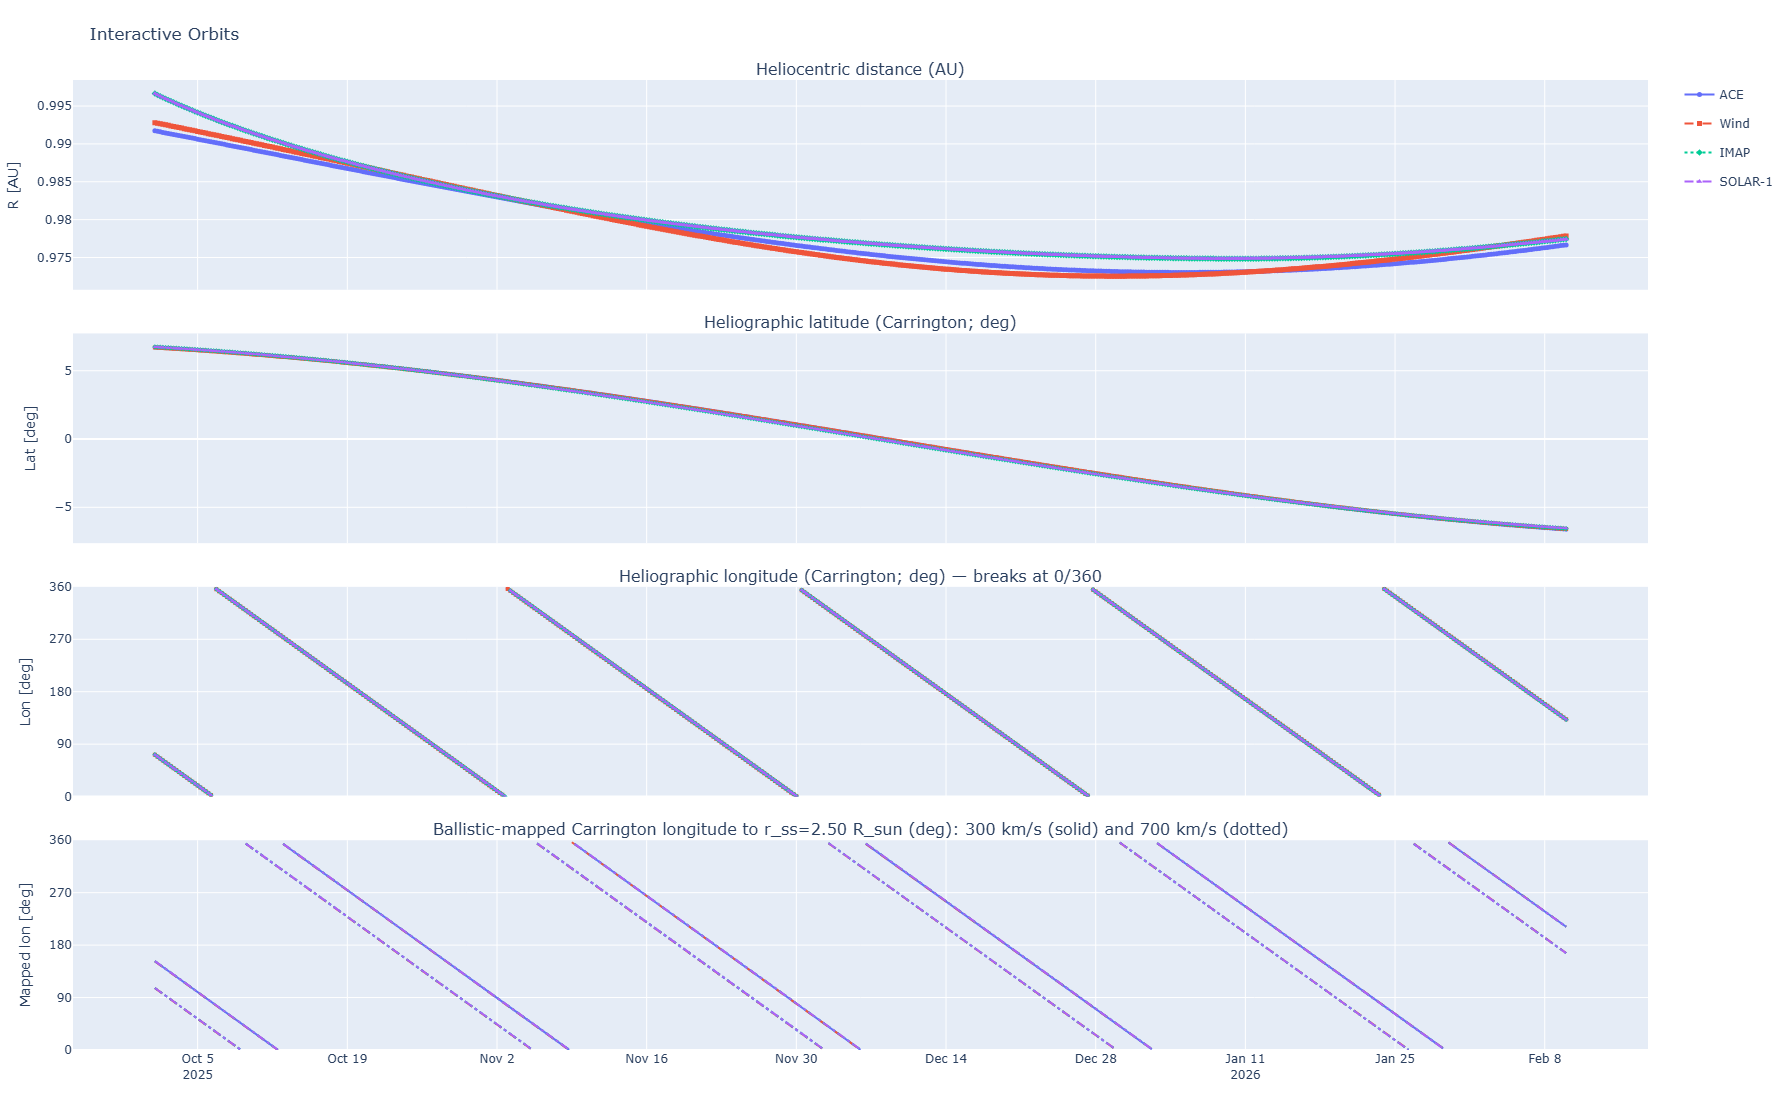

TypeError: build_3d_figure() got an unexpected keyword argument 'frame'

In [189]:
import os, sys
os.chdir(r"C:\Users\nokni\work\MHDTurbPy\functions\sc_pos")
sys.path.insert(0, os.getcwd())
import os, sys, importlib
os.chdir(r"C:\Users\nokni\work\MHDTurbPy\functions\sc_pos")
sys.path.insert(0, os.getcwd())

import helpers, horizons_sun_lonlat
importlib.reload(helpers)
importlib.reload(horizons_sun_lonlat)

from interactive_orbits_timeseries_plus3d import build_timeseries_figure, build_3d_figure

targets = [ "ACE", "Wind", "IMAP", "SOLAR-1"] # Discover, aditya 

fig_ts = build_timeseries_figure(
    targets=targets,
    start="2025-10-01T00:00:00",
    stop="2026-02-10T00:00:00",
    step="6h",
    rss_rsun=2.5,
    omega_deg_per_day=14.1844,
    width=1800,
    height=1100,
)
fig_ts.show()

fig_3d = build_3d_figure(
    targets=targets,
    start="2019-10-01T00:00:00",
    stop="2021-02-10T00:00:00",
    step="6h",
    frame="HCI",
    width=1800,
    height=900,
    show_ecliptic_plane=True,
    show_sun_surface_projection=True,
)
fig_3d.show()

#!python interactive_orbits_timeseries_plus3d.py --start 2026-02-01T00:00:00 --stop 2026-02-10T00:00:00 --step 6h --targets ACE Wind IMAP SOLAR-1 --html out_orbits/interactive_orbits_plus3d.html --frame3d HCI


12-Feb-26 07:52:43: Obtained JPL HORIZONS location for Earth (399)


[3D] Building 3D figure in frame3d=HCI (positions in AU).
INFO: Obtained JPL HORIZONS location for Earth (399) [sunpy.coordinates.ephemeris]


12-Feb-26 07:52:44: C:\Users\nokni\work\MHDTurbPy\functions\sc_pos\interactive_orbits_timeseries_plus3d.py:214: UserWarning:

Discarding nonzero nanoseconds in conversion.


12-Feb-26 07:52:44: Obtained JPL HORIZONS location for Parker Solar Probe (spacecraft)


INFO: Obtained JPL HORIZONS location for Parker Solar Probe (spacecraft) [sunpy.coordinates.ephemeris]


12-Feb-26 07:52:44: Obtained JPL HORIZONS location for Parker Solar Probe (spacecraft)


INFO: Obtained JPL HORIZONS location for Parker Solar Probe (spacecraft) [sunpy.coordinates.ephemeris]


12-Feb-26 07:52:46: Obtained JPL HORIZONS location for Parker Solar Probe (spacecraft)


INFO: Obtained JPL HORIZONS location for Parker Solar Probe (spacecraft) [sunpy.coordinates.ephemeris]


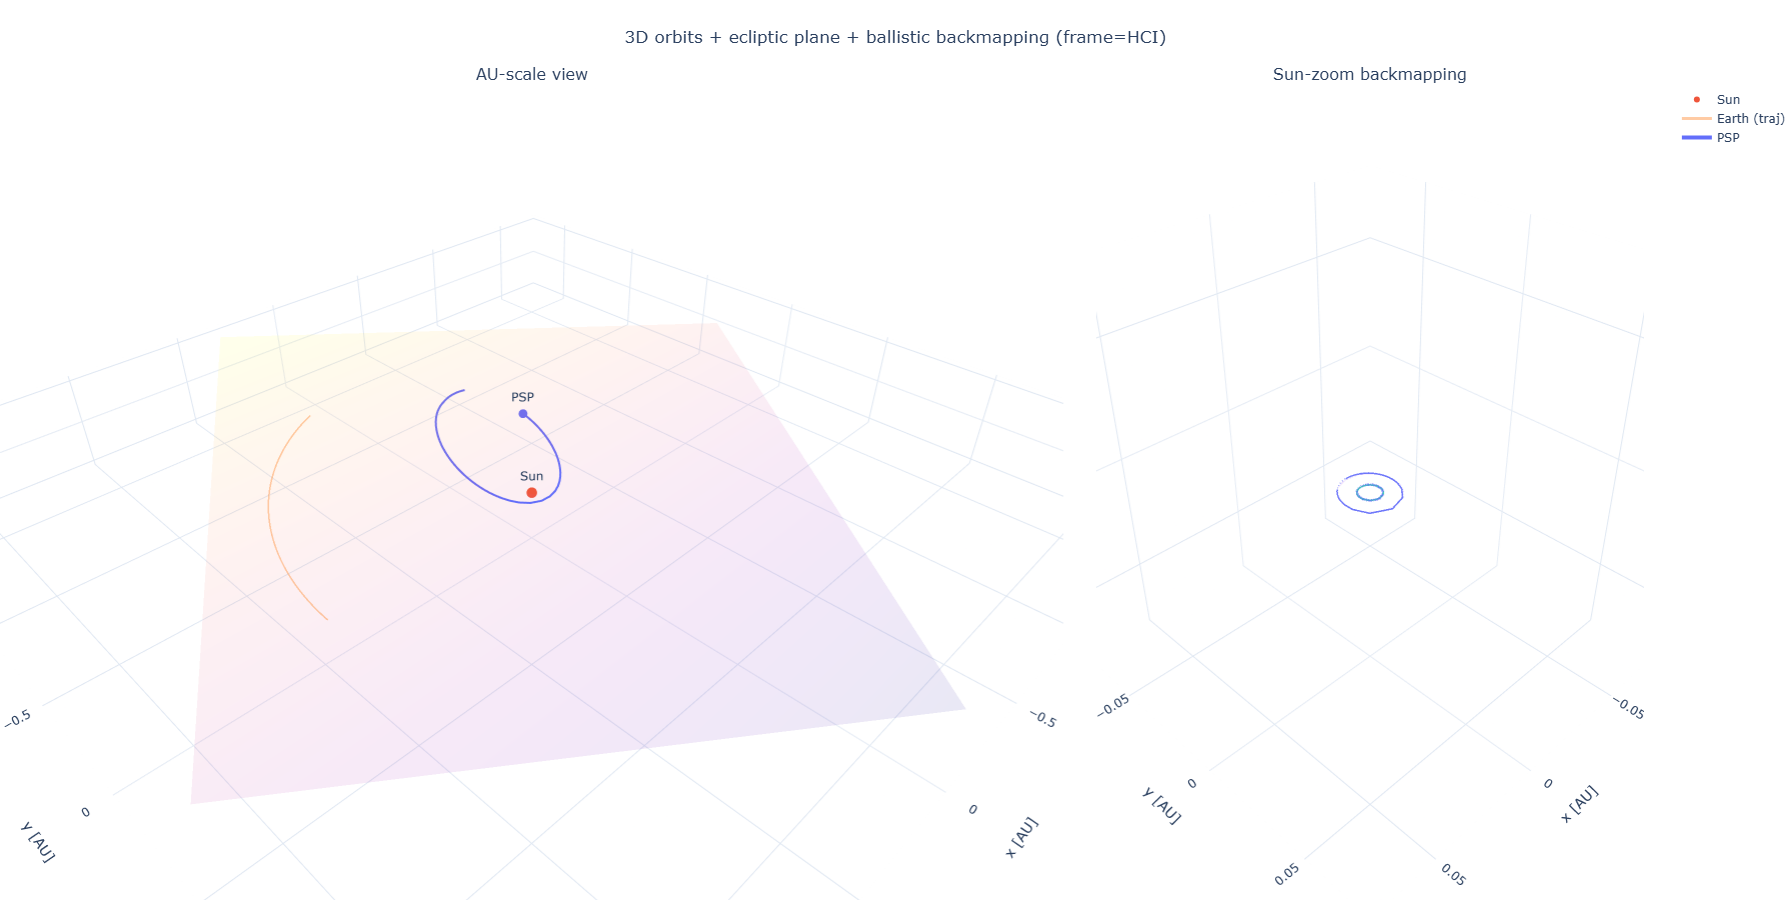

In [191]:
import os, sys, importlib
os.chdir(r"C:\Users\nokni\work\MHDTurbPy\functions\sc_pos")
sys.path.insert(0, os.getcwd())

import interactive_orbits_timeseries_plus3d as mod
importlib.reload(mod)

targets = ["PSP"]#, "Wind", "ACE"]

fig_3d = mod.build_3d_figure(
    targets=targets,
    start="2021-10-01T00:00:00",
    stop="2021-12-10T00:00:00",
    step="6h",
    frame3d="HCI",#"HEE",
    rss_rsun=2.5,
    omega_deg_per_day=14.1844,
    #vsw_kms=(300.0, 700.0),
    width=1800,
    height=900,
    sun_zoom_au=0.08,
    plane_span_au=1.2,
    show_spokes=True,
    spoke_count=10,
    decimate=2,
    verbose=True,
)
fig_3d.show()
